# Suffix Attribution Heatmap

Visualizes IG attribution for entire suffix predictions by reducing the 3D tensor `(features x prefix_steps x suffix_steps)` to 2D, showing only the **dominant feature** at each position.

**Note**: This shows only encoder (prefix) attributions. For encoder vs decoder split analysis, see `03_encoder_decoder_split.ipynb`. The decoder step attributions are computed with the encoder detached, making them incomparable to encoder attributions when shown side-by-side.

In [4]:
import sys
from pathlib import Path

_current = Path().resolve()
while _current != _current.parent:
    if (_current / 'src').is_dir():
        break
    _current = _current.parent
sys.path.insert(0, str(_current))
sys.path.insert(0, str(_current / 'src'))

import torch
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import TwoSlopeNorm

from src.interpretability.config.bpic17_config import CONFIG
from src.model.dropout_uncertainty_enc_dec_LSTM.dropout_uncertainty_model import DropoutUncertaintyEncoderDecoderLSTM
from src.evaluation.evaluation import Evaluation
from src.interpretability import InterpretabilityTool

%matplotlib inline

In [5]:
# Load model and data
model = DropoutUncertaintyEncoderDecoderLSTM.load(str(CONFIG.get_model_path()), dropout=0.0)
model.eval()
device = torch.device('cpu')
model = model.to(device)

test_dataset = torch.load(str(CONFIG.get_test_data_path()), weights_only=False)
eval_helper = Evaluation(model=model, dataset=test_dataset, concept_name=CONFIG.concept_name,
                         growing_num_values=CONFIG.growing_num_values, all_cat=CONFIG.all_cat, all_num=CONFIG.all_num)
tool = InterpretabilityTool(model, model.data_set_categories, device=device)

print(f"Cases: {len(eval_helper.cases)}, Suffix length: {model.seq_len_pred}")

Data set categories:  ([('concept:name', 28, {'A_Accepted': 1, 'A_Cancelled': 2, 'A_Complete': 3, 'A_Concept': 4, 'A_Create Application': 5, 'A_Denied': 6, 'A_Incomplete': 7, 'A_Pending': 8, 'A_Submitted': 9, 'A_Validating': 10, 'EOS': 11, 'O_Accepted': 12, 'O_Cancelled': 13, 'O_Create Offer': 14, 'O_Created': 15, 'O_Refused': 16, 'O_Returned': 17, 'O_Sent (mail and online)': 18, 'O_Sent (online only)': 19, 'W_Assess potential fraud': 20, 'W_Call after offers': 21, 'W_Call incomplete files': 22, 'W_Complete application': 23, 'W_Handle leads': 24, 'W_Personal Loan collection': 25, 'W_Shortened completion ': 26, 'W_Validate application': 27}), ('Action', 7, {'Created': 1, 'Deleted': 2, 'EOS': 3, 'Obtained': 4, 'Released': 5, 'statechange': 6}), ('org:resource', 151, {'EOS': 1, 'User_1': 2, 'User_10': 3, 'User_100': 4, 'User_101': 5, 'User_102': 6, 'User_103': 7, 'User_104': 8, 'User_105': 9, 'User_106': 10, 'User_107': 11, 'User_108': 12, 'User_109': 13, 'User_11': 14, 'User_110': 15, 'U

In [22]:
# Configuration
case_names = list(eval_helper.cases.keys())
CASE_NAME = "Application_1008477029" #case_names[1]
PREFIX_LENGTH = 5
TARGET = CONFIG.concept_name

print(f"Case: {CASE_NAME}, Prefix: {PREFIX_LENGTH}, Target: {TARGET}")

# Verify autoregressive behavior: check multiple cases with direct model inference
print("\n--- Autoregressive Verification (Direct Inference) ---")
import random
random.seed(42)
sample_cases = random.sample(case_names, min(10, len(case_names)))

# Get activity name mapping
activity_mapping = {v: k for k, v in model.data_set_categories[0][0][2].items()}

for case_name in sample_cases:
    case = eval_helper.cases[case_name]
    for pl, prefix, suffix in eval_helper._iterate_case(case):
        if pl >= 3:
            with torch.no_grad():
                # Model returns: predictions, (h,c), seq_len_pred, output_feature_indices
                predictions, _, _, _ = model((prefix[0], prefix[1]))
                cat_preds, num_preds = predictions
                
                # Get predicted activities for all 4 suffix steps
                activity_logits = cat_preds[f'{TARGET}_mean']  # [4, 1, n_classes]
                pred_classes = activity_logits.argmax(dim=-1).squeeze().tolist()
                if isinstance(pred_classes, int):
                    pred_classes = [pred_classes]
                pred_names = [activity_mapping.get(c, f"idx_{c}")[:15] for c in pred_classes]
                
            print(f"  {case_name[:20]:20s} (prefix={pl}): {' -> '.join(pred_names)}")
            break

print("\nNote: Repeated predictions are valid - the model may be confident about patterns.")

Case: Application_1008477029, Prefix: 5, Target: concept:name

--- Autoregressive Verification (Direct Inference) ---
  Application_67263963 (prefix=3): W_Handle leads -> W_Complete appl -> A_Concept -> W_Complete appl
  Application_12890164 (prefix=3): W_Handle leads -> W_Complete appl -> A_Concept -> W_Complete appl
  Application_10662684 (prefix=3): W_Handle leads -> W_Complete appl -> A_Concept -> W_Complete appl
  Application_92968755 (prefix=3): W_Complete appl -> W_Complete appl -> W_Complete appl -> W_Complete appl
  Application_16877909 (prefix=3): W_Handle leads -> W_Complete appl -> A_Concept -> W_Complete appl
  Application_16206926 (prefix=3): W_Handle leads -> W_Complete appl -> A_Concept -> W_Complete appl
  Application_15611485 (prefix=3): W_Handle leads -> W_Complete appl -> A_Concept -> W_Complete appl
  Application_13558596 (prefix=3): W_Handle leads -> W_Complete appl -> A_Concept -> W_Complete appl
  Application_91225120 (prefix=3): W_Handle leads -> W_Complete app

In [ ]:
def get_case_prefix(case_name, prefix_len, eval_helper):
    full_case = eval_helper.cases[case_name]
    for pl, prefix, suffix in eval_helper._iterate_case(full_case):
        if pl == prefix_len:
            return prefix
    raise ValueError(f"Prefix length {prefix_len} not found")

def compute_suffix_attributions(tool, prefix, prefix_len, target, n_steps=50):
    """Compute IG attributions for all suffix steps.
    
    Note: Only encoder (prefix) attributions are shown. Decoder step attributions
    are computed with the encoder detached, making them incomparable.
    For encoder/decoder split analysis, see 03_encoder_decoder_split.ipynb.
    """
    cat_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[0]]
    num_tensors = [t.squeeze(0) if t.dim() > 1 else t for t in prefix[1]]
    process = (cat_tensors, num_tensors)
    
    results, feature_names, prefix_labels = [], None, None
    
    for suffix_step in range(tool.model.seq_len_pred):
        try:
            attr_map = tool.compute_attribution_map(
                process=process, prefix_length=prefix_len, target=target,
                target_class='auto', suffix_scope='step', suffix_step=suffix_step,
                method='integrated_gradients', n_steps=n_steps
            )
            if feature_names is None:
                feature_names, prefix_labels = attr_map.feature_names, attr_map.step_labels
            
            results.append((suffix_step, attr_map, attr_map.target_description))
            
            # Print with convergence delta
            delta = attr_map.convergence_delta if attr_map.convergence_delta else "N/A"
            print(f"  Step {suffix_step}: {attr_map.target_description}")
            print(f"           Positions: {len(attr_map.step_labels)}, Convergence delta: {delta}")
            
            if 'EOS' in attr_map.target_description:
                break
        except Exception as e:
            print(f"  Step {suffix_step} error: {e}")
            break
    
    return results, feature_names, prefix_labels

# Compute
prefix = get_case_prefix(CASE_NAME, PREFIX_LENGTH, eval_helper)
print("Computing attributions...")
results, feature_names, prefix_labels = compute_suffix_attributions(
    tool, prefix, PREFIX_LENGTH, TARGET, n_steps=CONFIG.ig_steps
)

In [24]:
def build_cube_and_reduce(results, feature_names, prefix_labels):
    """Build 3D cube and reduce to 2D by selecting top 2 features.
    
    All suffix steps have the same prefix positions (no intermediate predictions).
    """
    n_features = len(feature_names)
    n_suffix = len(results)
    n_prefix = len(prefix_labels)
    
    cube = np.full((n_features, n_prefix, n_suffix), np.nan)
    suffix_labels = []
    
    for suffix_step, attr_map, pred_desc in results:
        suffix_labels.append(pred_desc.split('=')[1].split('(')[0].strip() if '=' in pred_desc else f"Step {suffix_step}")
        
        for feat_idx, feat_name in enumerate(feature_names):
            if feat_name in attr_map.attributions:
                vals = attr_map.attributions[feat_name]
                vals = vals.detach().cpu().numpy() if hasattr(vals, 'detach') else vals
                cube[feat_idx, :len(vals), suffix_step] = vals
    
    # Reduce: find top 2 features at each position
    magnitude_1st = np.full((n_prefix, n_suffix), np.nan)
    magnitude_2nd = np.full((n_prefix, n_suffix), np.nan)
    feature_name_1st = np.empty((n_prefix, n_suffix), dtype=object)
    feature_name_2nd = np.empty((n_prefix, n_suffix), dtype=object)
    
    for p in range(n_prefix):
        for s in range(n_suffix):
            if not np.all(np.isnan(cube[:, p, s])):
                abs_vals = np.abs(cube[:, p, s])
                sorted_idx = np.argsort(abs_vals)[::-1]  # Descending
                
                # First (dominant)
                feat_idx_1 = sorted_idx[0]
                magnitude_1st[p, s] = cube[feat_idx_1, p, s]
                feature_name_1st[p, s] = feature_names[feat_idx_1]
                
                # Second
                if len(sorted_idx) > 1:
                    feat_idx_2 = sorted_idx[1]
                    magnitude_2nd[p, s] = cube[feat_idx_2, p, s]
                    feature_name_2nd[p, s] = feature_names[feat_idx_2]
    
    return magnitude_1st, magnitude_2nd, feature_name_1st, feature_name_2nd, suffix_labels, prefix_labels, cube

mag_1st, mag_2nd, feat_1st, feat_2nd, suffix_labels, step_labels, cube = build_cube_and_reduce(results, feature_names, prefix_labels)
print(f"Cube: {cube.shape} -> Reduced: {mag_1st.shape}")
print(f"Step labels: {step_labels}")

Cube: (18, 5, 4) -> Reduced: (5, 4)
Step labels: ['A_Create Application', 'A_Submitted', 'W_Handle leads', 'W_Handle leads', 'W_Handle leads']


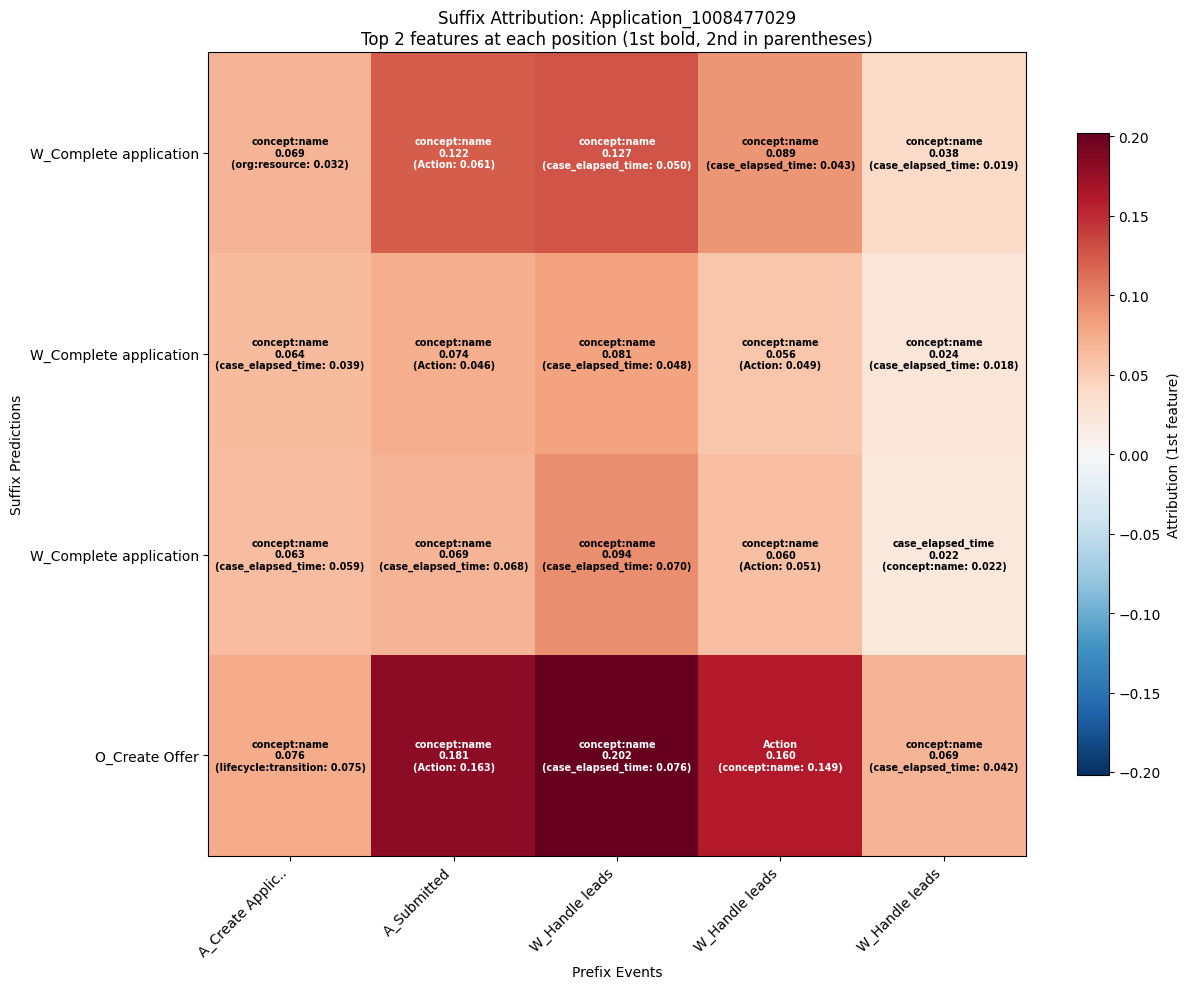

In [25]:
def plot_suffix_heatmap(mag_1st, mag_2nd, feat_1st, feat_2nd, step_labels, suffix_labels, case_name):
    """Plot 2D heatmap showing top 2 features at each (prefix, suffix) position.
    
    Shows dominant feature (bold) and second feature (smaller) in each cell.
    """
    data = mag_1st.T
    n_suffix, n_positions = data.shape
    
    fig, ax = plt.subplots(figsize=(max(12, n_positions * 2.5), max(5, n_suffix * 2.5)))
    
    # Create masked array for proper NaN handling
    masked_data = np.ma.masked_invalid(data)
    
    vmax = max(np.nanmax(np.abs(data)), 0.001)
    
    # Plot heatmap with gray for NaN
    cmap = plt.cm.RdBu_r.copy()
    cmap.set_bad(color='lightgray')
    im = ax.imshow(masked_data, cmap=cmap, norm=TwoSlopeNorm(vmin=-vmax, vcenter=0, vmax=vmax),
                   aspect='auto', interpolation='nearest')
    
    # Add cell annotations with top 2 features
    for i in range(n_suffix):
        for j in range(n_positions):
            if not np.isnan(data[i, j]):
                feat1 = feat_1st.T[i, j]
                val1 = mag_1st.T[i, j]
                feat2 = feat_2nd.T[i, j]
                val2 = mag_2nd.T[i, j]
                
                color = 'white' if abs(val1) > vmax * 0.5 else 'black'
                
                # First feature (bold, larger)
                text = f"{feat1}\n{val1:.3f}"
                # Second feature (smaller, below)
                if feat2 is not None and not np.isnan(val2):
                    text += f"\n({feat2}: {val2:.3f})"
                
                ax.text(j, i, text, ha='center', va='center',
                       color=color, fontsize=7, fontweight='bold')
    
    ax.set_xticks(range(n_positions))
    ax.set_xticklabels([l[:15] + '..' if len(l) > 15 else l for l in step_labels], rotation=45, ha='right')
    ax.set_yticks(range(n_suffix))
    ax.set_yticklabels(suffix_labels)
    ax.set_xlabel('Prefix Events')
    ax.set_ylabel('Suffix Predictions')
    ax.set_title(f'Suffix Attribution: {case_name}\nTop 2 features at each position (1st bold, 2nd in parentheses)')
    plt.colorbar(im, ax=ax, label='Attribution (1st feature)', shrink=0.8)
    ax.grid(False)
    plt.tight_layout()
    return fig

fig = plot_suffix_heatmap(mag_1st, mag_2nd, feat_1st, feat_2nd, step_labels, suffix_labels, CASE_NAME)
plt.show()